# Fiscal Predictive Model · next-day revenue and expense
**Hakeem · Fiscal Impact · SparkCity**

Predict **next-calendar-day mean revenue and expense per observation**, using information available after the preceding day closes. These are not city totals or convention-effect predictions.

The proposed convention remains April 7–9, 2027. Historical data ends January 10, 2026; this one-day experiment cannot validate a forecast more than a year later. The separate convention scenarios remain explicit assumptions.

**Assessment focus:** Spark ingestion/validation and compact aggregation; leakage-safe modeling; measured performance; saved model inference; held-out metrics and charts; optional transactional PostgreSQL persistence; reproducible documentation. No S2 connection or dashboard modification occurs by default.

Run with the project `.venv` after `uv sync --dev`. Restart a stale Spark kernel before Run All.


In [1]:
import json
import hashlib
import time
import platform
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, FileLink
from sparkcityx.day5 import select_sources, dataset_hash
from sparkcityx.day5_pipeline import start_spark
from sparkcityx.fiscal_forecast import (
    aggregate_fiscal_spark, chronological_parts, evaluate_forecasts,
    predict_candidate, predict_next_day, make_features, calendar_data,
)
from sparkcityx.fiscal_forecast_store import validate_publication, publish_forecast

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "src/sparkcityx").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Start inside SparkCity_Capstone.")
DAY4_RUN = "20260914T205935811311Z"
APPLY_DATABASE = False
INITIALIZE_FORECAST_TABLES = False
if INITIALIZE_FORECAST_TABLES and not APPLY_DATABASE:
    raise ValueError("Schema creation requires database opt-in.")
day4, day3, source_manifest, previous = select_sources(ROOT, DAY4_RUN)
expected = next(r["rows"] for r in previous["features"] if r["dataset"] == "fiscal")
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUTPUT = ROOT / "data/processed/fiscal_model" / RUN_ID
OUTPUT.mkdir(parents=True, exist_ok=False)
MODELS = OUTPUT / "models"
(OUTPUT / "manifest.json").write_text(json.dumps({"status": "running", "run_id": RUN_ID}))
spark = start_spark()
sns.set_theme(style="whitegrid")
timings, charts = {}, []
print("Source:", day3)
print("Output:", OUTPUT)
print("Database writes enabled:", APPLY_DATABASE)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/17 16:38:25 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Source: /Users/hakeem/Projects/SparkCity_Capstone/data/processed/day3/20260914T142210469836Z
Output: /Users/hakeem/Projects/SparkCity_Capstone/data/processed/fiscal_model/20260917T203823771265Z
Database writes enabled: False


## 1. Spark ingestion, quality and efficient transformation
Read only required fiscal columns from the hash-verified Day 3 Parquet snapshot. Reuse a cached projection for validation and aggregation, then unpersist it. Nulls, duplicates, ranges, finite values and blank IDs are checked. Collect only the daily aggregates, not the full sensor dataset.

Fixed two local workers/four shuffle partitions suit this small educational workload, not a claim of production tuning. Record actual runtime instead of claiming a universal optimization speedup.


In [2]:
started = time.perf_counter()
daily, validation_report = aggregate_fiscal_spark(spark, day3 / "features/fiscal", expected)
timings["spark_validation_aggregation_seconds"] = time.perf_counter() - started
daily.to_csv(OUTPUT / "daily_input.csv")
display(daily.head())
print(f"{expected:,} observations -> {len(daily)} daily rows collected")
print("Date range:", daily.index.min().date(), "through", daily.index.max().date())
display(pd.Series(timings))


,revenue,expense,observations,sensors
day,,,,
2025-01-01,210.976458,94.577917,96,96
2025-01-02,195.334479,83.389375,96,96
2025-01-03,246.243958,106.596771,96,96
2025-01-04,238.876042,91.137500,96,96
2025-01-05,260.424271,79.892188,96,96


36,000 observations -> 375 daily rows collected
Date range: 2025-01-01 through 2026-01-10


spark_validation_aggregation_seconds    5.603655
dtype: float64

## 2. Feature availability and chronological partitions
Target day d uses revenue/expense on d−1 and d−7, prior 7-/28-day means ending d−1, and the known weekday of d. No target-day revenue, expense, outlier flag, occupancy, location, or generator multiplier enters the features.

Calendar coverage is partitioned before excluding unavailable rows:
**60% training → 15% model selection → 10% interval calibration → 15% final test**.
The first 28 days warm up lag features. Missing calendar days remain missing and invalidate affected histories.

Testing is **rolling one-day-ahead**: once an earlier test day has actually finished, its observed values may inform the next prediction. This is not a multi-day forecast issued once at the test boundary. Coefficients and preprocessing remain frozen.


In [3]:
data, features, parts, split_audit = chronological_parts(daily)
display(split_audit)
display(features.dropna().head())
assert parts["train"].max() < parts["validation"].min()
assert parts["validation"].max() < parts["calibration"].min()
assert parts["calibration"].max() < parts["test"].min()
assert split_audit.calendar_days.sum() == len(data)
split_audit.to_csv(OUTPUT / "split_audit.csv", index=False)
print("Features:", features.columns.tolist())
print("Usable training rows:", len(parts["train"]))


,partition,calendar_days,usable_days,excluded_days,calendar_start,calendar_end,first_target,last_target
0,train,225,197,28,2025-01-01,2025-08-13,2025-01-29,2025-08-13
1,validation,56,56,0,2025-08-14,2025-10-08,2025-08-14,2025-10-08
2,calibration,37,37,0,2025-10-09,2025-11-14,2025-10-09,2025-11-14
3,test,57,57,0,2025-11-15,2026-01-10,2025-11-15,2026-01-10


,revenue_lag1,revenue_lag7,revenue_past7_mean,revenue_past28_mean,expense_lag1,expense_lag7,expense_past7_mean,expense_past28_mean,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
day,,,,,,,,,,,,,,
2025-01-29,194.623750,193.703333,221.162917,226.360149,94.320521,107.389583,95.904717,96.251696,0.0,1.0,0.0,0.0,0.0,0.0
2025-01-30,186.612396,200.099167,220.149926,225.490004,93.570833,94.173542,93.930610,96.215729,0.0,0.0,1.0,0.0,0.0,0.0
2025-01-31,197.124271,205.013958,219.724940,225.553925,99.748854,85.930521,94.727083,96.799996,0.0,0.0,0.0,1.0,0.0,0.0
2025-02-01,201.101875,226.867604,219.166071,223.941708,86.243437,95.419271,94.771786,96.073092,0.0,0.0,0.0,0.0,1.0,0.0
2025-02-02,252.461146,299.839688,222.822292,224.426890,103.696875,98.099583,95.954301,96.521641,0.0,0.0,0.0,0.0,0.0,1.0


Features: ['revenue_lag1', 'revenue_lag7', 'revenue_past7_mean', 'revenue_past28_mean', 'expense_lag1', 'expense_lag7', 'expense_past7_mean', 'expense_past28_mean', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6']
Usable training rows: 197


## 3. Train and select models
For each target compare:
- Training mean, yesterday, same weekday last week, and trailing seven-day mean.
- Ridge regression with fixed penalties 1, 10 and 100. Training-only centering/scaling and coefficients are exported as JSON; NumPy solves this small daily-table regression transparently.
- A **PySpark ML Pipeline** using VectorAssembler and a fixed 30-tree random forest (depth 3, minimum 10 observations per leaf, seed 42).

Select the lowest **validation RMSE**, allowing a baseline to win. All candidates have nonnegative predictions under the same clipping policy. Do not change features or settings based on test performance. The forest is persisted and reloaded for scoring. Models are not refitted on calibration or test dates.


In [4]:
started = time.perf_counter()
artifact, selection_metrics, test_metrics, predictions, split_audit = evaluate_forecasts(
    daily, spark=spark, model_directory=MODELS)
timings["training_selection_calibration_test_seconds"] = time.perf_counter() - started
display(selection_metrics.sort_values(["target", "rmse"]))
display(test_metrics)
for target, config in artifact["models"].items():
    print(target, "selected:", config["model"]["name"])
selection_metrics.to_csv(OUTPUT / "validation_metrics.csv", index=False)
test_metrics.to_csv(OUTPUT / "test_metrics.csv", index=False)
predictions.to_csv(OUTPUT / "test_predictions.csv", index=False)


Fitting revenue: 197 training days, 8 candidates


revenue: validation selected ridge_100; RMSE=30.5602
Fitting expense: 197 training days, 8 candidates
expense: validation selected spark_random_forest; RMSE=8.3730


,target,model,rows,rmse,mae,bias,r2
15,expense,spark_random_forest,56,8.373017,6.804530,-0.066508,0.004409
8,expense,training_mean,56,8.396515,6.904853,0.289126,-0.001187
14,expense,ridge_100,56,8.573798,6.984935,0.235132,-0.043911
13,expense,ridge_10,56,8.691100,7.156403,0.515544,-0.072671
12,expense,ridge_1,56,8.769715,7.269708,0.853235,-0.092165
11,expense,trailing_7d,56,8.956630,7.403355,-0.022202,-0.139217
10,expense,last_week,56,11.189653,9.184418,0.173198,-0.778076
9,expense,yesterday,56,11.612911,9.259118,0.025629,-0.915135
6,revenue,ridge_100,56,30.560194,24.191082,12.965265,0.205788
5,revenue,ridge_10,56,30.809351,24.580678,14.697987,0.192785


,target,model,selected,rows,rmse,mae,bias,r2
0,revenue,training_mean,False,57,74.574680,70.378774,70.378774,-8.143839
1,revenue,yesterday,False,57,34.294350,28.395587,-1.616000,-0.933708
2,revenue,last_week,False,57,25.947105,20.021182,0.231943,-0.106939
3,revenue,trailing_7d,False,57,25.525327,20.382692,-0.809990,-0.071244
4,revenue,ridge_100,True,57,28.939089,24.037379,21.364947,-0.376941
5,expense,training_mean,False,57,6.909823,5.412394,-0.359007,-0.002707
6,expense,yesterday,False,57,9.976974,7.648346,0.002783,-1.090441
7,expense,last_week,False,57,8.735567,6.753876,0.147286,-0.602590
8,expense,trailing_7d,False,57,7.283222,5.706635,0.149631,-0.114005
9,expense,spark_random_forest,True,57,7.010499,5.493724,0.043759,-0.032139


revenue selected: ridge_100
expense selected: spark_random_forest


## 4. Held-out accuracy and uncertainty
RMSE emphasizes large errors; MAE gives average absolute error; signed bias shows over-/underprediction; R² compares with the held-out mean and may be negative. Compare models **within each target**, on identical dates.

Absolute residuals from the separate calibration period set a fixed nominal 90% band radius for the selected model. Temporal dependence and distribution changes mean 90% coverage is **not guaranteed**. Report actual test coverage and average band width. Bands describe daily-mean forecast errors, not uncertainty in total convention receipts.

The same calibration period does not select the model. If results are weak, report that rather than choosing a different model using the test interval.


,test_days,empirical_coverage,mean_band_width
target,,,
expense,57,0.947368,27.071818
revenue,57,0.982456,115.840062


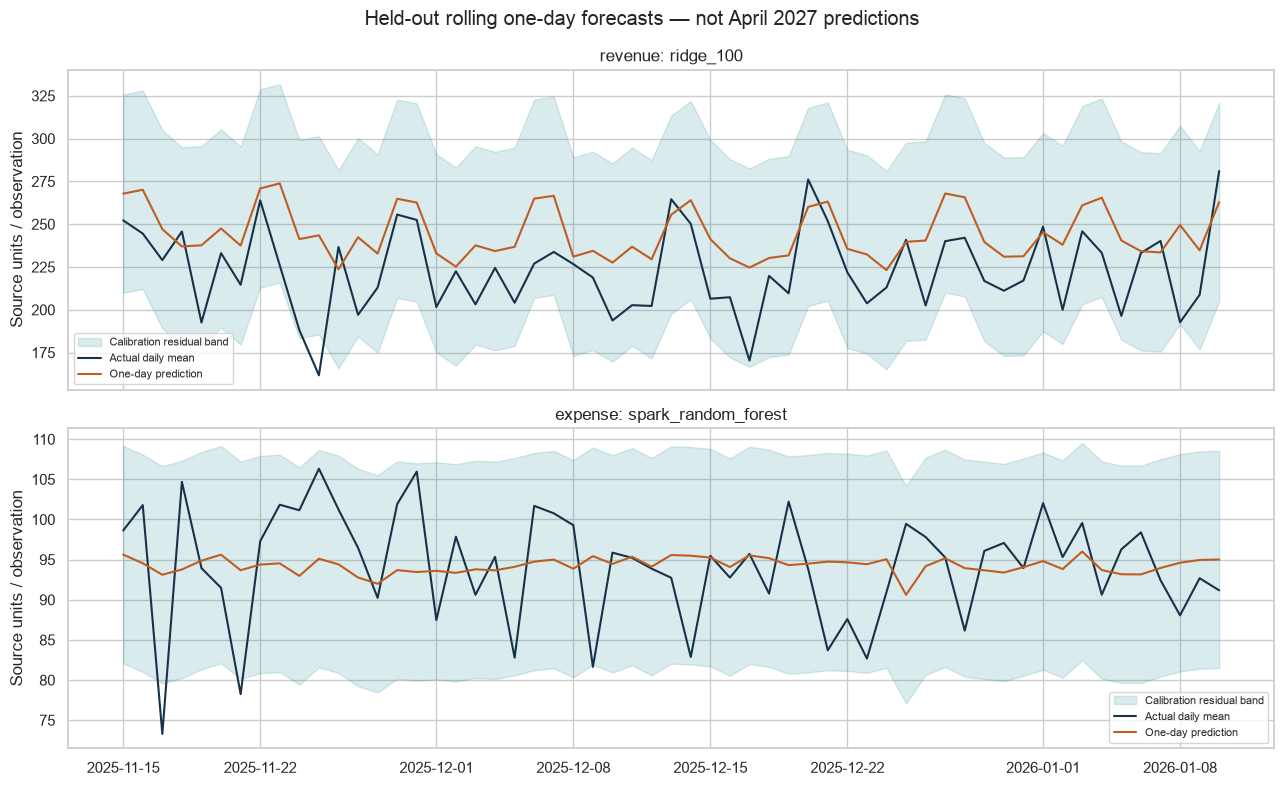

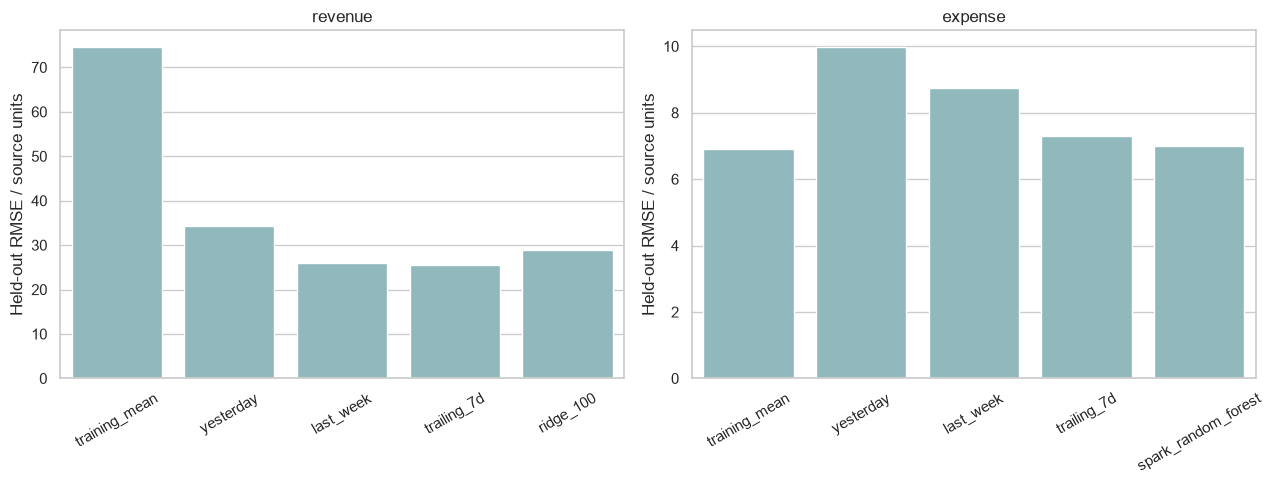

In [5]:
coverage = predictions.groupby("target").agg(test_days=("day", "size"),
    empirical_coverage=("covered", "mean"))
coverage["mean_band_width"] = predictions.assign(width=predictions.upper-predictions.lower).groupby("target").width.mean()
display(coverage)
coverage.to_csv(OUTPUT / "interval_coverage.csv")
def save_chart(fig, name):
    fig.savefig(OUTPUT / (name + ".png"), dpi=145, bbox_inches="tight")
    charts.append(name + ".png")
    if plt.get_backend().lower() != "agg":
        plt.show()
    plt.close(fig)
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for ax, target in zip(axes, ["revenue", "expense"]):
    group = predictions[predictions.target == target]
    dates = pd.to_datetime(group.day)
    ax.fill_between(dates, group.lower, group.upper, color="#087e8b", alpha=.15, label="Calibration residual band")
    ax.plot(dates, group.actual, color="#173149", label="Actual daily mean")
    ax.plot(dates, group.prediction, color="#be5d20", label="One-day prediction")
    ax.set(title=f"{target}: {artifact['models'][target]['model']['name']}", ylabel="Source units / observation")
    ax.legend(fontsize=8)
fig.suptitle("Held-out rolling one-day forecasts — not April 2027 predictions")
fig.tight_layout()
save_chart(fig, "01_forecast_backtest")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, target in zip(axes, ["revenue", "expense"]):
    group = test_metrics[test_metrics.target == target]
    sns.barplot(group, x="model", y="rmse", color="#88bec5", errorbar=None, ax=ax)
    ax.set(title=target, xlabel="", ylabel="Held-out RMSE / source units")
    ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
save_chart(fig, "02_baseline_comparison")


## 5. Residual diagnostics and anomaly-review handoff
A reading outside its forecast band is a **review candidate**, not a confirmed financial incident. This complements the earlier fiscal notebook's prior-only median/MAD flags. Neither method has incident labels, so precision/recall and false-positive rates remain unknown.

Inspect time dependence in errors and bias. A model can have small average error while missing particular periods. Model coefficients and forest patterns do not establish causality.


,mean,std,min,max,lag1_residual_correlation
target,,,,,
expense,-0.043759,7.072678,-19.825225,12.507012,0.006265
revenue,-21.364947,19.692985,-81.719690,18.096135,-0.132382


,target,day,origin_day,actual,prediction,lower,upper,covered,residual,outside_band
10,revenue,2025-11-25,2025-11-24,161.737604,243.457294,185.537263,301.377326,False,-81.719690,True
59,expense,2025-11-17,2025-11-16,73.288125,93.113350,79.577440,106.649259,False,-19.825225,True
63,expense,2025-11-21,2025-11-20,78.248750,93.677865,80.141956,107.213775,False,-15.429115,True
81,expense,2025-12-09,2025-12-08,81.640000,95.430613,81.894704,108.966522,False,-13.790613,True


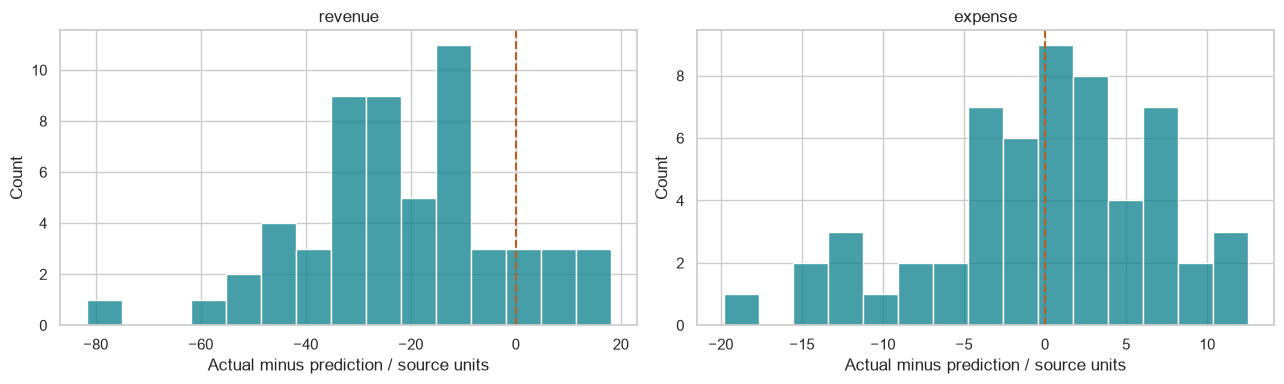

In [6]:
predictions["residual"] = predictions.actual - predictions.prediction
predictions["outside_band"] = ~predictions.covered
review = predictions[predictions.outside_band].copy()
review.to_csv(OUTPUT / "forecast_review_candidates.csv", index=False)
diagnostics = predictions.groupby("target").residual.agg(["mean", "std", "min", "max"])
diagnostics["lag1_residual_correlation"] = predictions.groupby("target").residual.apply(lambda s: s.autocorr(1))
display(diagnostics)
display(review.head(10))
diagnostics.to_csv(OUTPUT / "residual_diagnostics.csv")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, target in zip(axes, ["revenue", "expense"]):
    group = predictions[predictions.target == target]
    sns.histplot(group, x="residual", bins=15, color="#087e8b", ax=ax)
    ax.axvline(0, color="#be5d20", linestyle="--")
    ax.set(title=target, xlabel="Actual minus prediction / source units")
fig.tight_layout()
save_chart(fig, "03_residual_diagnostics")


## 6. Saved-model inference and the next available day
Round-trip the JSON model artifact and verify identical predictions for held-out dates. If a Spark forest wins, its model directory must accompany the JSON. The artifact is model data, not an executable pickle.

The next forecast is **January 11, 2026** for the pinned snapshot, based on January 10 information. It is not a current-date forecast, April 2027 projection or estimate of convention-induced revenue. Do not recursively extend it hundreds of days and treat the result as validated.


In [7]:
(OUTPUT / "model.json").write_text(json.dumps(artifact, indent=2, allow_nan=False))
restored = json.loads((OUTPUT / "model.json").read_text())
for target, config in restored["models"].items():
    reproduced = predict_candidate(config["model"], features.loc[parts["test"]],
                                   spark=spark, model_directory=MODELS)
    exported = predictions[predictions.target == target].prediction.to_numpy()
    assert np.allclose(reproduced, exported, rtol=1e-10, atol=1e-10)
started = time.perf_counter()
next_day = predict_next_day(restored, daily, spark=spark, model_directory=MODELS)
timings["saved_next_day_inference_seconds"] = time.perf_counter() - started
next_day.to_csv(OUTPUT / "next_day_forecast.csv", index=False)
display(next_day)
print("Saved-model inference verified; horizon is one day only.")


,target,origin_day,target_day,horizon_days,model,prediction,lower,upper
0,revenue,2026-01-10,2026-01-11,1,ridge_100,266.801650,208.881619,324.721681
1,expense,2026-01-10,2026-01-11,1,spark_random_forest,94.329572,80.793663,107.865482


Saved-model inference verified; horizon is one day only.


## 7. Model card, reproducibility and database-ready handoff
Write a model card with data lineage, split dates, features, baseline performance, band coverage, limitations and measured timings. Only completed, hash-verified exports should reach the Fiscal Impact page.

Spark aggregates the source; the driver handles just 375 daily rows. No performance comparison or scalability claim is inferred from a single run. JSON holds the ridge/baseline state; Spark model files are retained alongside it. The optional database schema stores versioned predictions and metrics; source tables remain untouched.


In [8]:
timings.update({"spark_version": spark.version, "spark_master": spark.sparkContext.master,
    "shuffle_partitions": spark.conf.get("spark.sql.shuffle.partitions"), "platform": platform.platform(),
    "source_rows": expected, "collected_daily_rows": len(daily)})
(OUTPUT / "performance.json").write_text(json.dumps(timings, indent=2))
source_info = {"day4_run": day4.name, "day3_run": day3.name,
    "day2_run": source_manifest["day2_run"], "day1_run": source_manifest["day1_run"],
    "fiscal_input_sha256": source_manifest["input_sha256"]["fiscal"],
    "timestamp_semantics": source_manifest.get("timestamp_semantics"),
    "source_units": "unconfirmed source currency units per observation",
    "source_start": str(data.index.min().date()), "source_end": str(data.index.max().date()),
    "forecast_module_sha256": hashlib.sha256((ROOT / "src/sparkcityx/fiscal_forecast.py").read_bytes()).hexdigest()}
lines = ["# Fiscal predictive model", "",
    "Task: next-day average revenue and expense, not city totals or convention impact.",
    "Target event April 7–9, 2027 is outside the validated one-day horizon.", "",
    "## Evaluation"]
for target in ["revenue", "expense"]:
    selected = test_metrics[(test_metrics.target == target) & test_metrics.selected].iloc[0]
    baseline = test_metrics[(test_metrics.target == target) & (test_metrics.model == "training_mean")].iloc[0]
    skill = 1-selected.rmse/baseline.rmse if baseline.rmse else np.nan
    best_baseline = test_metrics[(test_metrics.target == target) & test_metrics.model.isin(['training_mean', 'yesterday', 'last_week', 'trailing_7d'])].sort_values('rmse').iloc[0]
    lines += [f"- {target}: {selected.model}; test RMSE {selected.rmse:.3f}, MAE {selected.mae:.3f}, "
              f"R² {selected.r2:.3f}; RMSE improvement vs training mean {skill:.1%}.",
              f"  Empirical band coverage {coverage.loc[target, 'empirical_coverage']:.1%} on "
              f"{int(coverage.loc[target, 'test_days'])} held-out days.",
              f"  Strongest baseline observed on test: {best_baseline.model}, RMSE {best_baseline.rmse:.3f}. Selected model beats it: {bool(selected.rmse < best_baseline.rmse)}. This comparison does not reselect the model."]
lines += ["", "## Limitations",
    "- Experimental forecast: successful execution is not evidence of operational predictive skill.",
    "- Synthetic data, one seasonal cycle, moving sensor locations and unconfirmed accounting units.",
    "- Selection is by validation RMSE only; calibration and test follow chronologically.",
    "- Rolling test predictions use prior observed test days, not future values.",
    "- Negative predictions are clipped consistently; band coverage is empirical, not guaranteed.",
    "- Review flags have no incident labels; no alert-accuracy or causal-effect claim.",
    "- Mean daily readings are not financial totals, city profit, or event receipts.",
    "- Database publication and dashboard integration are separate opt-in steps."]
(OUTPUT / "model_card.md").write_text("\n".join(lines) + "\n")
publication = {"status": "complete", "run_id": RUN_ID, "provenance": source_info,
    "artifact": artifact, "metrics": json.loads(test_metrics.to_json(orient="records")),
    "predictions": json.loads(predictions.to_json(orient="records")),
    "next_day": json.loads(next_day.to_json(orient="records"))}
validate_publication(publication)
(OUTPUT / "publication.json").write_text(json.dumps(publication, indent=2, allow_nan=False))
select_sources(ROOT, DAY4_RUN)
manifest = {"status": "complete", "run_id": RUN_ID, "provenance": source_info,
    "horizon_days": 1, "database_publication": "not_attempted", "charts": charts,
    "artifacts_sha256": {p.name: hashlib.sha256(p.read_bytes()).hexdigest()
        for p in OUTPUT.iterdir() if p.is_file() and p.name != "manifest.json"},
    "spark_models_sha256": dataset_hash(MODELS)}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2))
display(Markdown("\n".join(lines)))
print("Completed local model:", OUTPUT)


# Fiscal predictive model

Task: next-day average revenue and expense, not city totals or convention impact.
Target event April 7–9, 2027 is outside the validated one-day horizon.

## Evaluation
- revenue: ridge_100; test RMSE 28.939, MAE 24.037, R² -0.377; RMSE improvement vs training mean 61.2%.
  Empirical band coverage 98.2% on 57 held-out days.
  Strongest baseline observed on test: trailing_7d, RMSE 25.525. Selected model beats it: False. This comparison does not reselect the model.
- expense: spark_random_forest; test RMSE 7.010, MAE 5.494, R² -0.032; RMSE improvement vs training mean -1.5%.
  Empirical band coverage 94.7% on 57 held-out days.
  Strongest baseline observed on test: training_mean, RMSE 6.910. Selected model beats it: False. This comparison does not reselect the model.

## Limitations
- Experimental forecast: successful execution is not evidence of operational predictive skill.
- Synthetic data, one seasonal cycle, moving sensor locations and unconfirmed accounting units.
- Selection is by validation RMSE only; calibration and test follow chronologically.
- Rolling test predictions use prior observed test days, not future values.
- Negative predictions are clipped consistently; band coverage is empirical, not guaranteed.
- Review flags have no incident labels; no alert-accuracy or causal-effect claim.
- Mean daily readings are not financial totals, city profit, or event receipts.
- Database publication and dashboard integration are separate opt-in steps.

Completed local model: /Users/hakeem/Projects/SparkCity_Capstone/data/processed/fiscal_model/20260917T203823771265Z


## 8. Optional PostgreSQL persistence
Disabled by default. After team approval, set APPLY_DATABASE=True. First deployment additionally needs INITIALIZE_FORECAST_TABLES=True and schema permissions. Uses ignored `secrets/.env` and the shared SSL-enforcing helper.

Run ID + identical content is a no-op; changed content under the same ID is rejected. Model metadata, predictions and the publication pointer commit together. No source data is updated. Test this path against an isolated database before S2 deployment.


In [9]:
if APPLY_DATABASE:
    from dotenv import load_dotenv
    from sparkcityx.database import connect_database
    load_dotenv(ROOT / "secrets/.env", override=False)
    with connect_database() as connection:
        if INITIALIZE_FORECAST_TABLES:
            with connection.transaction(), connection.cursor() as cursor:
                cursor.execute((ROOT / "sql/003_fiscal_forecasts.sql").read_text())
        receipt = publish_forecast(connection, publication)
    with connect_database() as connection:
        assert publish_forecast(connection, publication)["status"] == "unchanged"
    (OUTPUT / "publication_receipt.json").write_text(json.dumps(receipt, indent=2))
    print(receipt)
else:
    print("SKIPPED: no database connection or publication requested.")
# spark.stop() when finished with this kernel.


SKIPPED: no database connection or publication requested.
